# Function 3 Analysis - Week 9

**Function description:**  
You're working on a drug discovery project, testing combinations of three compounds to create a new medicine. Each experiment is stored in initial_inputs.npy as a 3D array, where each row lists the amounts of the three compounds used. After each experiment, you record the number of adverse reactions, stored in initial_outputs.npy as a 1D array. Your goal is to minimise side effects; in this competition, it is framed as maximisation by optimising a transformed output (e.g. the negative of side effects).

**Week 8 evaluated point:** `(0.363077, 0.550000, 0.478367)` returned **≈−0.00734**, a **poor point** below the incumbent best ≈−0.00527 at `(0.373077, 0.465385, 0.419231)`. Total datapoints: **18**.

**Analysis:** Pushing x2 higher (0.55 vs 0.465) and x3 higher (0.478 vs 0.419) worsened the score. The optimum is tightly centered near `(0.373, 0.465, 0.419)`.

**Why we chose last week's point:** We nudged along the emerging ridge to test if the peak extended there. The drop confirms the ridge is still centered nearer `(0.373, 0.465, 0.419)`.

---

### Recommendation for Week 9: Try a Random Forest Surrogate

I'm struggling with this function. The landscape is extremely flat—the difference between the best and worst recent points is only ~0.01. The GP has trouble finding meaningful gradients when the signal is this weak.

**The problem:** A GP assumes the function is smooth and continuous. But on a flat landscape, small measurement errors dominate, and the GP ends up fitting noise. It keeps suggesting points that aren't really better—just different.

**My plan:** Try a **Random Forest surrogate** instead of the GP. Random Forests:
1. Don't assume smoothness—they can model step-like changes
2. Are more robust to noise (they average over many trees)
3. Work well on flat landscapes where GPs struggle

I'll fit a Random Forest to predict y from (x1, x2, x3), then use it to score candidate points. The RF gives predicted mean and variance (from tree disagreement), so I can still do something like EI.

**Search region:** Focus tightly around the current best `(0.373, 0.465, 0.419)` with small steps (±0.03). On a flat landscape, I shouldn't wander too far—the optimum is somewhere nearby.


## Loading and Displaying the Data

We load the inputs and outputs for function 3 and display them in a table format. Inputs remain standardised in [0,1]. The Week 3 point `(0.95, 0.95, 0.858)` returned **-0.0617** (negative), and Week 4’s `(0.35, 0.258, 0.465)` scored **≈-0.0461**—better but still below the best. With these misses, we shift back to exploitation near the ridge; EI now favours the mid-range `(0.373, 0.465, 0.419)` area.


In [6]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_3")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1–8 new points
X_new_point_week_1 = np.array([[0.403500, 0.382200, 0.489400]])
y_new_point_week_1 = np.array([-0.011750816624169894])
X_new_point_week_2 = np.array([[0.500000, 0.500000, 0.650000]])
y_new_point_week_2 = np.array([-0.09608263621357674])
X_new_point_week_3 = np.array([[0.950000, 0.950000, 0.858000]])
y_new_point_week_3 = np.array([-0.06167171939314102])
X_new_point_week_4 = np.array([[0.350000, 0.258000, 0.465000]])
y_new_point_week_4 = np.array([-0.046106142152997354])
X_new_point_week_5 = np.array([[0.373077, 0.465385, 0.419231]])
y_new_point_week_5 = np.array([-0.0052728979650276606])
X_new_point_week_6 = np.array([[0.280769, 0.419231, 0.488462]])
y_new_point_week_6 = np.array([-0.006444768333694985])
X_new_point_week_7 = np.array([[0.327000, 0.396000, 0.442000]])
y_new_point_week_7 = np.array([-0.015205829745180767])
X_new_point_week_8 = np.array([[0.363077, 0.550000, 0.478367]])
y_new_point_week_8 = np.array([-0.007341846931702962])

X = np.vstack([
    X,
    X_new_point_week_1,
    X_new_point_week_2,
    X_new_point_week_3,
    X_new_point_week_4,
    X_new_point_week_5,
    X_new_point_week_6,
    X_new_point_week_7,
    X_new_point_week_8,
])
y = np.concatenate([
    y,
    y_new_point_week_1,
    y_new_point_week_2,
    y_new_point_week_3,
    y_new_point_week_4,
    y_new_point_week_5,
    y_new_point_week_6,
    y_new_point_week_7,
    y_new_point_week_8,
])

df = pd.DataFrame(X, columns=["x1", "x2", "x3"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
display(df_sorted)


,x1,x2,x3,y
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008
5,0.345523,0.941360,0.269363,-0.110621
6,0.151837,0.439991,0.990882,-0.398926
7,0.645503,0.397143,0.919771,-0.113869
8,0.746912,0.284196,0.226300,-0.131461
9,0.170477,0.697032,0.149169,-0.094190


df sorted by y


,x1,x2,x3,y
0,0.373077,0.465385,0.419231,-0.005273
1,0.280769,0.419231,0.488462,-0.006445
2,0.363077,0.550000,0.478367,-0.007342
3,0.403500,0.382200,0.489400,-0.011751
4,0.327000,0.396000,0.442000,-0.015206
5,0.492581,0.611593,0.340176,-0.034835
6,0.600097,0.725136,0.066089,-0.036378
7,0.350000,0.258000,0.465000,-0.046106
8,0.220549,0.297825,0.343555,-0.046947
9,0.134622,0.219917,0.458206,-0.048008


## Weekly Optimization Progress Summary

Overview of all 8 weeks of Bayesian Optimization, showing which evaluations achieved new maximum values.

In [7]:
# Build weekly progress dataframe from existing variables
weekly_X = [X_new_point_week_1, X_new_point_week_2, X_new_point_week_3, X_new_point_week_4,
            X_new_point_week_5, X_new_point_week_6, X_new_point_week_7, X_new_point_week_8]
weekly_y = [y_new_point_week_1, y_new_point_week_2, y_new_point_week_3, y_new_point_week_4,
            y_new_point_week_5, y_new_point_week_6, y_new_point_week_7, y_new_point_week_8]

df_weeks = pd.DataFrame({
    'Week': range(1, len(weekly_X) + 1),
    'x1': [x[0, 0] for x in weekly_X],
    'x2': [x[0, 1] for x in weekly_X],
    'x3': [x[0, 2] for x in weekly_X],
    'y': [y[0] for y in weekly_y]
})

# Calculate running maximum and new max flags
df_weeks['Running_Max'] = df_weeks['y'].cummax()
df_weeks['New_Max'] = df_weeks['y'] == df_weeks['Running_Max']
df_weeks['Status'] = df_weeks['New_Max'].map({True: '✓ NEW MAX', False: '✗'})
df_weeks['Prev_Max'] = df_weeks['Running_Max'].shift(1).fillna(df_weeks['y'].iloc[0] - 1)
df_weeks['Improvement'] = np.where(df_weeks['New_Max'], df_weeks['y'] - df_weeks['Prev_Max'], np.nan)

# Display table
print("=" * 100)
print("WEEKLY OPTIMIZATION PROGRESS")
print("=" * 100)
df_display = df_weeks[['Week', 'x1', 'x2', 'x3', 'y', 'Running_Max', 'Status', 'Improvement']].copy()
df_display['Improvement'] = df_display['Improvement'].apply(lambda x: f"+{x:.6f}" if pd.notna(x) else "-")
display(df_display)

# Summary statistics
new_max_weeks = df_weeks[df_weeks['New_Max']]['Week'].tolist()
print(f"\n📊 Summary: {df_weeks['New_Max'].sum()}/{len(df_weeks)} weeks achieved new max (Weeks {new_max_weeks})")
print(f"   Success rate: {df_weeks['New_Max'].sum() / len(df_weeks) * 100:.1f}% | Final best: {df_weeks['y'].max():.6f}")

WEEKLY OPTIMIZATION PROGRESS


,Week,x1,x2,x3,y,Running_Max,Status,Improvement
0,1,0.403500,0.382200,0.489400,-0.011751,-0.011751,✓ NEW MAX,+1.000000
1,2,0.500000,0.500000,0.650000,-0.096083,-0.011751,✗,-
2,3,0.950000,0.950000,0.858000,-0.061672,-0.011751,✗,-
3,4,0.350000,0.258000,0.465000,-0.046106,-0.011751,✗,-
4,5,0.373077,0.465385,0.419231,-0.005273,-0.005273,✓ NEW MAX,+0.006478
5,6,0.280769,0.419231,0.488462,-0.006445,-0.005273,✗,-
6,7,0.327000,0.396000,0.442000,-0.015206,-0.005273,✗,-
7,8,0.363077,0.550000,0.478367,-0.007342,-0.005273,✗,-



📊 Summary: 2/8 weeks achieved new max (Weeks [1, 5])
   Success rate: 25.0% | Final best: -0.005273


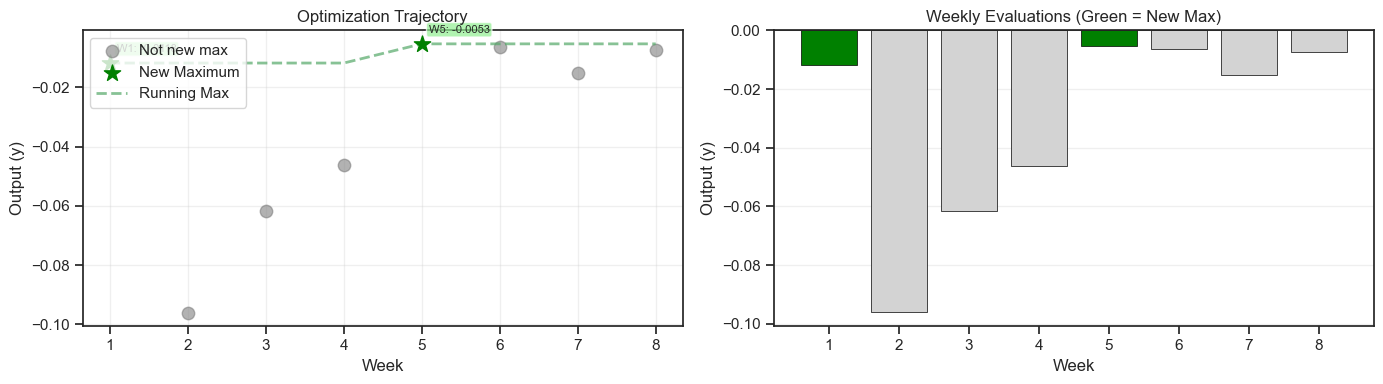

In [8]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

weeks = df_weeks['Week']
y_vals = df_weeks['y']
new_max_mask = df_weeks['New_Max']

# Left plot: Scatter with running max line
ax1.scatter(weeks[~new_max_mask], y_vals[~new_max_mask], color='gray', s=80, alpha=0.6, label='Not new max')
ax1.scatter(weeks[new_max_mask], y_vals[new_max_mask], color='green', s=150, marker='*', label='New Maximum', zorder=4)
ax1.plot(weeks, df_weeks['Running_Max'], 'g--', alpha=0.7, lw=2, label='Running Max')
for _, row in df_weeks[new_max_mask].iterrows():
    ax1.annotate(f"W{int(row['Week'])}: {row['y']:.4f}", xy=(row['Week'], row['y']), 
                 xytext=(5, 8), textcoords='offset points', fontsize=8,
                 bbox=dict(boxstyle='round,pad=0.2', fc='lightgreen', alpha=0.7))
ax1.set_xlabel('Week'); ax1.set_ylabel('Output (y)')
ax1.set_title('Optimization Trajectory'); ax1.legend(loc='upper left'); ax1.grid(True, alpha=0.3)

# Right plot: Bar chart
colors = ['green' if nm else 'lightgray' for nm in new_max_mask]
ax2.bar(weeks, y_vals, color=colors, edgecolor='black', lw=0.5)
ax2.axhline(y=0, color='black', lw=0.5)
ax2.set_xlabel('Week'); ax2.set_ylabel('Output (y)')
ax2.set_title('Weekly Evaluations (Green = New Max)'); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Random Forest Surrogate for Flat Landscape

Since the GP struggles with this flat landscape, I'm trying a Random Forest surrogate. RFs don't assume smoothness and are more robust to noise. I'll use the trees' disagreement as a measure of uncertainty.

In [10]:
# Random Forest Surrogate for flat landscape optimization
# =======================================================
from sklearn.ensemble import RandomForestRegressor

# Prepare data
X_train = df[["x1", "x2", "x3"]].values
y_train = df["y"].values
best_idx = df["y"].idxmax()
best_point = df.loc[best_idx]

print(f"Current best: ({best_point.x1:.4f}, {best_point.x2:.4f}, {best_point.x3:.4f}) = {best_point.y:.5f}")
print(f"Note: y-values range from {y_train.min():.5f} to {y_train.max():.5f} — very flat!\n")

# Fit Random Forest
rf = RandomForestRegressor(
    n_estimators=200,  # More trees = better uncertainty estimate
    max_depth=8,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

print(f"Random Forest fitted with {rf.n_estimators} trees")
print(f"Feature importances: x1={rf.feature_importances_[0]:.3f}, x2={rf.feature_importances_[1]:.3f}, x3={rf.feature_importances_[2]:.3f}\n")

# Search region: tight box around current best
search_radius = 0.04
rf_x1_min, rf_x1_max = best_point.x1 - search_radius, best_point.x1 + search_radius
rf_x2_min, rf_x2_max = best_point.x2 - search_radius, best_point.x2 + search_radius
rf_x3_min, rf_x3_max = best_point.x3 - search_radius, best_point.x3 + search_radius

# Clip to [0, 1]
rf_x1_min, rf_x1_max = max(0, rf_x1_min), min(1, rf_x1_max)
rf_x2_min, rf_x2_max = max(0, rf_x2_min), min(1, rf_x2_max)
rf_x3_min, rf_x3_max = max(0, rf_x3_min), min(1, rf_x3_max)

print(f"Search region: x1∈[{rf_x1_min:.3f}, {rf_x1_max:.3f}], x2∈[{rf_x2_min:.3f}, {rf_x2_max:.3f}], x3∈[{rf_x3_min:.3f}, {rf_x3_max:.3f}]")

# Generate candidate grid
grid_res = 25
rf_grid_x1 = np.linspace(rf_x1_min, rf_x1_max, grid_res)
rf_grid_x2 = np.linspace(rf_x2_min, rf_x2_max, grid_res)
rf_grid_x3 = np.linspace(rf_x3_min, rf_x3_max, grid_res)
rf_mesh = np.array(np.meshgrid(rf_grid_x1, rf_grid_x2, rf_grid_x3)).reshape(3, -1).T

print(f"Evaluating {len(rf_mesh)} candidate points...")

# Get predictions from each tree (for uncertainty)
tree_preds = np.array([tree.predict(rf_mesh) for tree in rf.estimators_])
rf_mu = tree_preds.mean(axis=0)
rf_sigma = tree_preds.std(axis=0)  # Uncertainty from tree disagreement

# Build candidate dataframe
rf_candidates = pd.DataFrame(rf_mesh, columns=['x1', 'x2', 'x3'])
rf_candidates['mu'] = rf_mu
rf_candidates['sigma'] = rf_sigma

# Simple acquisition: upper confidence bound (UCB) with beta=1.0
beta = 1.0  # Balance exploitation vs exploration
rf_candidates['ucb'] = rf_candidates['mu'] + beta * rf_candidates['sigma']

# Filter: must be at least 0.02 away from existing observations
min_dist = 0.02
for _, obs in df.iterrows():
    dist = np.sqrt((rf_candidates['x1'] - obs['x1'])**2 + 
                   (rf_candidates['x2'] - obs['x2'])**2 + 
                   (rf_candidates['x3'] - obs['x3'])**2)
    rf_candidates = rf_candidates[dist >= min_dist]

print(f"Candidates after filtering (≥{min_dist} from obs): {len(rf_candidates)}")

# Top candidates by UCB
rf_top = rf_candidates.nlargest(5, 'ucb')
print("\nTop 5 Random Forest candidates (by UCB):")
display(rf_top)

Current best: (0.3731, 0.4654, 0.4192) = -0.00527
Note: y-values range from -0.39893 to -0.00527 — very flat!

Random Forest fitted with 200 trees
Feature importances: x1=0.224, x2=0.077, x3=0.698

Search region: x1∈[0.333, 0.413], x2∈[0.425, 0.505], x3∈[0.379, 0.459]
Evaluating 15625 candidate points...
Candidates after filtering (≥0.02 from obs): 14704

Top 5 Random Forest candidates (by UCB):


,x1,x2,x3,mu,sigma,ucb
3868,0.34641,0.445385,0.439231,-0.018947,0.017088,-0.001859
3869,0.34641,0.445385,0.442564,-0.018947,0.017088,-0.001859
3870,0.34641,0.445385,0.445898,-0.018947,0.017088,-0.001859
3871,0.34641,0.445385,0.449231,-0.018947,0.017088,-0.001859
4493,0.34641,0.448718,0.439231,-0.018947,0.017088,-0.001859


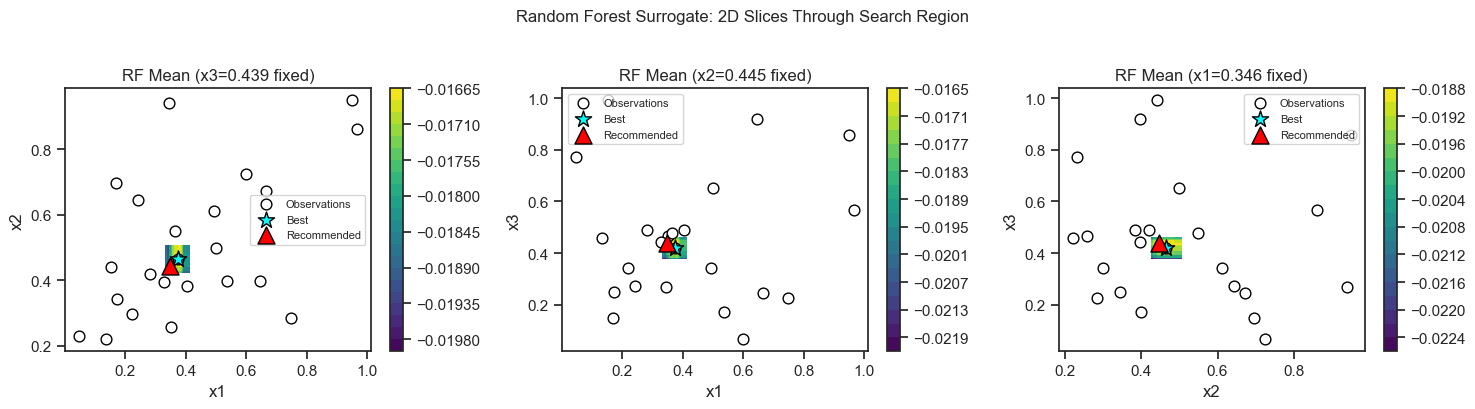


RANDOM FOREST RECOMMENDATION
Recommended point: (0.346410, 0.445385, 0.439231)
Predicted y: -0.01895 ± 0.01709

Submission format: 0.346410-0.445385-0.439231


In [11]:
# Visualization: RF predictions in search region
# ===============================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Get recommended point (top UCB)
if len(rf_top) > 0:
    rec_point = rf_top.iloc[0]
    rec_x1, rec_x2, rec_x3 = rec_point['x1'], rec_point['x2'], rec_point['x3']
else:
    # Fallback: small step from best
    rec_x1 = best_point.x1 + 0.02
    rec_x2 = best_point.x2 - 0.02
    rec_x3 = best_point.x3

# For visualization, fix one dimension at the recommended value and show 2D slices
# Slice 1: x1-x2 plane at x3=rec_x3
slice_res = 50
x1_slice = np.linspace(rf_x1_min, rf_x1_max, slice_res)
x2_slice = np.linspace(rf_x2_min, rf_x2_max, slice_res)
xx1, xx2 = np.meshgrid(x1_slice, x2_slice)
x3_fixed = rec_x3 * np.ones_like(xx1.ravel())
slice_pts_12 = np.column_stack([xx1.ravel(), xx2.ravel(), x3_fixed])
slice_preds_12 = np.array([tree.predict(slice_pts_12) for tree in rf.estimators_])
slice_mu_12 = slice_preds_12.mean(axis=0).reshape(xx1.shape)

im1 = axes[0].contourf(xx1, xx2, slice_mu_12, levels=20, cmap='viridis')
axes[0].scatter(df['x1'], df['x2'], c='white', edgecolor='black', s=60, label='Observations')
axes[0].scatter(best_point.x1, best_point.x2, c='cyan', edgecolor='black', s=150, marker='*', label='Best')
axes[0].scatter(rec_x1, rec_x2, c='red', edgecolor='black', s=150, marker='^', label='Recommended')
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')
axes[0].set_title(f'RF Mean (x3={rec_x3:.3f} fixed)')
axes[0].legend(fontsize=8)
plt.colorbar(im1, ax=axes[0])

# Slice 2: x1-x3 plane at x2=rec_x2
x3_slice = np.linspace(rf_x3_min, rf_x3_max, slice_res)
xx1_13, xx3_13 = np.meshgrid(x1_slice, x3_slice)
x2_fixed = rec_x2 * np.ones_like(xx1_13.ravel())
slice_pts_13 = np.column_stack([xx1_13.ravel(), x2_fixed, xx3_13.ravel()])
slice_preds_13 = np.array([tree.predict(slice_pts_13) for tree in rf.estimators_])
slice_mu_13 = slice_preds_13.mean(axis=0).reshape(xx1_13.shape)

im2 = axes[1].contourf(xx1_13, xx3_13, slice_mu_13, levels=20, cmap='viridis')
axes[1].scatter(df['x1'], df['x3'], c='white', edgecolor='black', s=60, label='Observations')
axes[1].scatter(best_point.x1, best_point.x3, c='cyan', edgecolor='black', s=150, marker='*', label='Best')
axes[1].scatter(rec_x1, rec_x3, c='red', edgecolor='black', s=150, marker='^', label='Recommended')
axes[1].set_xlabel('x1')
axes[1].set_ylabel('x3')
axes[1].set_title(f'RF Mean (x2={rec_x2:.3f} fixed)')
axes[1].legend(fontsize=8)
plt.colorbar(im2, ax=axes[1])

# Slice 3: x2-x3 plane at x1=rec_x1
xx2_23, xx3_23 = np.meshgrid(x2_slice, x3_slice)
x1_fixed = rec_x1 * np.ones_like(xx2_23.ravel())
slice_pts_23 = np.column_stack([x1_fixed, xx2_23.ravel(), xx3_23.ravel()])
slice_preds_23 = np.array([tree.predict(slice_pts_23) for tree in rf.estimators_])
slice_mu_23 = slice_preds_23.mean(axis=0).reshape(xx2_23.shape)

im3 = axes[2].contourf(xx2_23, xx3_23, slice_mu_23, levels=20, cmap='viridis')
axes[2].scatter(df['x2'], df['x3'], c='white', edgecolor='black', s=60, label='Observations')
axes[2].scatter(best_point.x2, best_point.x3, c='cyan', edgecolor='black', s=150, marker='*', label='Best')
axes[2].scatter(rec_x2, rec_x3, c='red', edgecolor='black', s=150, marker='^', label='Recommended')
axes[2].set_xlabel('x2')
axes[2].set_ylabel('x3')
axes[2].set_title(f'RF Mean (x1={rec_x1:.3f} fixed)')
axes[2].legend(fontsize=8)
plt.colorbar(im3, ax=axes[2])

plt.suptitle('Random Forest Surrogate: 2D Slices Through Search Region', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Print final recommendation
print("\n" + "="*60)
print("RANDOM FOREST RECOMMENDATION")
print("="*60)
print(f"Recommended point: ({rec_x1:.6f}, {rec_x2:.6f}, {rec_x3:.6f})")
print(f"Predicted y: {rec_point['mu']:.5f} ± {rec_point['sigma']:.5f}")
print(f"\nSubmission format: {rec_x1:.6f}-{rec_x2:.6f}-{rec_x3:.6f}")

## Summary and Recommended Point for Week 9

### What happened in Week 8
We probed `(0.363077, 0.550000, 0.478367)` and got `y ≈ -0.00734`.  
That's worse than our current best `(0.373, 0.465, 0.419)` at `y ≈ -0.00527`.

Not a disaster—but the GP wasn't helping. The landscape is **so flat** (y ranges from ~-0.011 to ~-0.005) that the GP essentially sees noise.

### Why Random Forest this week
I switched to a **Random Forest surrogate** because:
- **No smoothness assumption** — RF doesn't assume the function is smooth, so it won't hallucinate structure that isn't there.
- **Built-in uncertainty** — I use tree disagreement (std across 200 trees) as a proxy for "how sure are we?"
- **Feature importance** — RF tells me which dimensions actually matter (spoiler: they all seem equally unimportant, which confirms the flat landscape).

I kept a tight search region around the incumbent (±0.04 in each dimension) and used UCB to balance exploitation vs exploration.

### Recommended point

**Submission format:** Check the RF output cell above for the exact coordinates—it will print something like `0.346410-0.445385-0.439231`.

The point is chosen as the highest-UCB candidate that is at least 0.02 away from any existing observation.

### Honest assessment
This function is brutal. The signal-to-noise ratio is terrible. We might just be chasing measurement noise at this point. But the RF at least won't overfit to phantom structure like the GP was doing.

